In [2]:
from collections import Counter
from PIL import Image, ImageOps, ImageEnhance
from pathlib import Path
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix
from pillow_heif import register_heif_opener

import cv2
import os
import shutil
import matplotlib.pyplot as plt
import random
import splitfolders
import torch
import torch.nn as nn
import torch.optim as optim
import time
import seaborn as sns
import numpy as np

In [3]:
NUMBER_OF_CLASS_SPLITS = 10     # Minimum number of images per class to be included
TARGET_COUNT = 100               # Target number of images per class after augmentation
IMAGE_SIZE = 214                # Image size for resizing (214x214)

DATASET_PATH = os.path.expanduser('~/Desktop/WildSnap-Dataset-copy')
DATASET_PATH_OBJ = Path(DATASET_PATH).expanduser()
DATASET_PLUS = Path(f'~/Desktop/WildSnap-Train-{NUMBER_OF_CLASS_SPLITS}plus').expanduser()
DATASET_PLUS_SIZE = Path(f'~/Desktop/WildSnap-Final-{IMAGE_SIZE}').expanduser()
DATASET_PLUS_SIZE_SPLIT = Path('~/Desktop/WildSnap-Split-Data').expanduser()

# Default ImageNet normalization values (do not change these if using Pre-trained Model)
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD = [0.229, 0.224, 0.225]

EXPORT_MODEL = 'wildsnap_model.pth'

# 1. Exploratory Data Analysis

## Summarize Dataset

In [4]:
def summarize_dataset(path):    
    if not os.path.exists(path):
        print("Folder not found. Please check the folder name and try again.")
        return

    report = []
    total_images = 0
    
    for folder_name in sorted(os.listdir(path)):
        folder_full_path = os.path.join(path, folder_name)
        
        # Detect only directories
        if os.path.isdir(folder_full_path):
            # Count image files in the folder (only .png, .jpg, .jpeg)
            images = [f for f in os.listdir(folder_full_path) 
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            
            count = len(images)
            report.append((folder_name, count))
            total_images += count

    print("-" * 40)
    print(f"{'Animal':<25} | {'Image Count':<10}")
    print("-" * 40)
    
    for name, count in report:
        status = "✅ Ready" if count >= NUMBER_OF_CLASS_SPLITS else "⚠️ Too few"
        print(f"{name:<25} | {count:<10} {status}")
        
    print("-" * 40)
    print(f"Total: {len(report)} categories | {total_images} images")

In [5]:
summarize_dataset(DATASET_PATH)

----------------------------------------
Animal                    | Image Count
----------------------------------------
African_Pygmy_Dormouse    | 4          ⚠️ Too few
Albino_Siamese_Crocodile  | 25         ✅ Ready
Ball_Python               | 35         ✅ Ready
Black-headed_Caique       | 29         ✅ Ready
Blue-and-gold_Macaw       | 84         ✅ Ready
Blue-tongued_Skink        | 23         ✅ Ready
Budapest_Pigeon           | 22         ✅ Ready
Budgerigar                | 14         ✅ Ready
Burmese_Python            | 25         ✅ Ready
Cockatiel                 | 8          ⚠️ Too few
Cuviers_Dwarf_Caiman      | 22         ✅ Ready
Golden_Burmese_Python     | 19         ✅ Ready
Gouldian_Finch            | 81         ✅ Ready
Green-cheeked_Conure      | 23         ✅ Ready
Grey_Crowned_Crane        | 53         ✅ Ready
Grey_Parrot               | 32         ✅ Ready
Iguana                    | 73         ✅ Ready
Madagascar_Giant_Day_Gecko | 86         ✅ Ready
Meerkat                  

## Summariza Image Size

In [5]:
def summarize_file_extensions(base_path):
    base_path = Path(base_path)
    ext_counter = Counter()

    for class_dir in base_path.iterdir():
        if class_dir.is_dir():
            for file_path in class_dir.iterdir():
                if file_path.is_file():
                    ext = file_path.suffix.lower()
                    if ext:
                        ext_counter[ext] += 1

    return ext_counter

In [6]:
summarize_file_extensions(DATASET_PATH)

Counter({'.jpg': 832,
         '.jpeg': 341,
         '.heic': 155,
         '.png': 43,
         '.mp4': 1,
         '.webp': 1})

## Corrupted Images

In [7]:
def find_broken_images(base_path):
    base_path = Path(base_path)
    broken = []

    for class_dir in base_path.iterdir():
        if class_dir.is_dir():
            for img_path in class_dir.iterdir():
                try:
                    Image.open(img_path).verify()
                except Exception:
                    broken.append(img_path)

    return broken


In [8]:
find_broken_images(DATASET_PATH)

[PosixPath('/Users/smileymacz/Desktop/WildSnap-Dataset-copy/Gouldian_Finch/IMG_6015.HEIC'),
 PosixPath('/Users/smileymacz/Desktop/WildSnap-Dataset-copy/Gouldian_Finch/IMG_6019.HEIC'),
 PosixPath('/Users/smileymacz/Desktop/WildSnap-Dataset-copy/Gouldian_Finch/IMG_6018.HEIC'),
 PosixPath('/Users/smileymacz/Desktop/WildSnap-Dataset-copy/Gouldian_Finch/.DS_Store'),
 PosixPath('/Users/smileymacz/Desktop/WildSnap-Dataset-copy/Gouldian_Finch/IMG_6015 (3).HEIC'),
 PosixPath('/Users/smileymacz/Desktop/WildSnap-Dataset-copy/Gouldian_Finch/IMG_6171.HEIC'),
 PosixPath('/Users/smileymacz/Desktop/WildSnap-Dataset-copy/Gouldian_Finch/IMG_6014.HEIC'),
 PosixPath('/Users/smileymacz/Desktop/WildSnap-Dataset-copy/Gouldian_Finch/IMG_6015 (1).HEIC'),
 PosixPath('/Users/smileymacz/Desktop/WildSnap-Dataset-copy/Gouldian_Finch/IMG_6176.HEIC'),
 PosixPath('/Users/smileymacz/Desktop/WildSnap-Dataset-copy/Gouldian_Finch/IMG_6009.HEIC'),
 PosixPath('/Users/smileymacz/Desktop/WildSnap-Dataset-copy/Gouldian_Finch/I

## Visual EDA

In [9]:
# Display random samples from random classes
def visual_eda(base_path, num_samples=5):
    base_path = Path(base_path).expanduser()

    # Randomly select 3 subdirectories (classes)
    subdirs = [d for d in base_path.iterdir() if d.is_dir() and not d.name.startswith('.')]
    
    if not subdirs:
        print("No subdirectories found in the specified path.")
        return

    selected_classes = random.sample(subdirs, min(3, len(subdirs)))
    
    # Create subplots to show images
    fig, axes = plt.subplots(len(selected_classes), num_samples, figsize=(15, 10))
    
    if len(selected_classes) == 1:
        axes = axes.reshape(1, -1)

    for i, class_path in enumerate(selected_classes):
        images = [img for img in class_path.iterdir() 
                  if img.suffix.lower() in ['.jpg', '.jpeg', '.png'] 
                  and not img.name.startswith('.')]
        
        if not images:
            print(f"No images found in folder: {class_path.name}")
            continue

        samples = random.sample(images, min(num_samples, len(images)))
        
        for j, img_path in enumerate(samples):
            img = Image.open(img_path)
            axes[i, j].imshow(img)
            axes[i, j].set_title(f"{class_path.name}", fontsize=10)
            axes[i, j].axis('off')
            
    plt.tight_layout()
    plt.show()

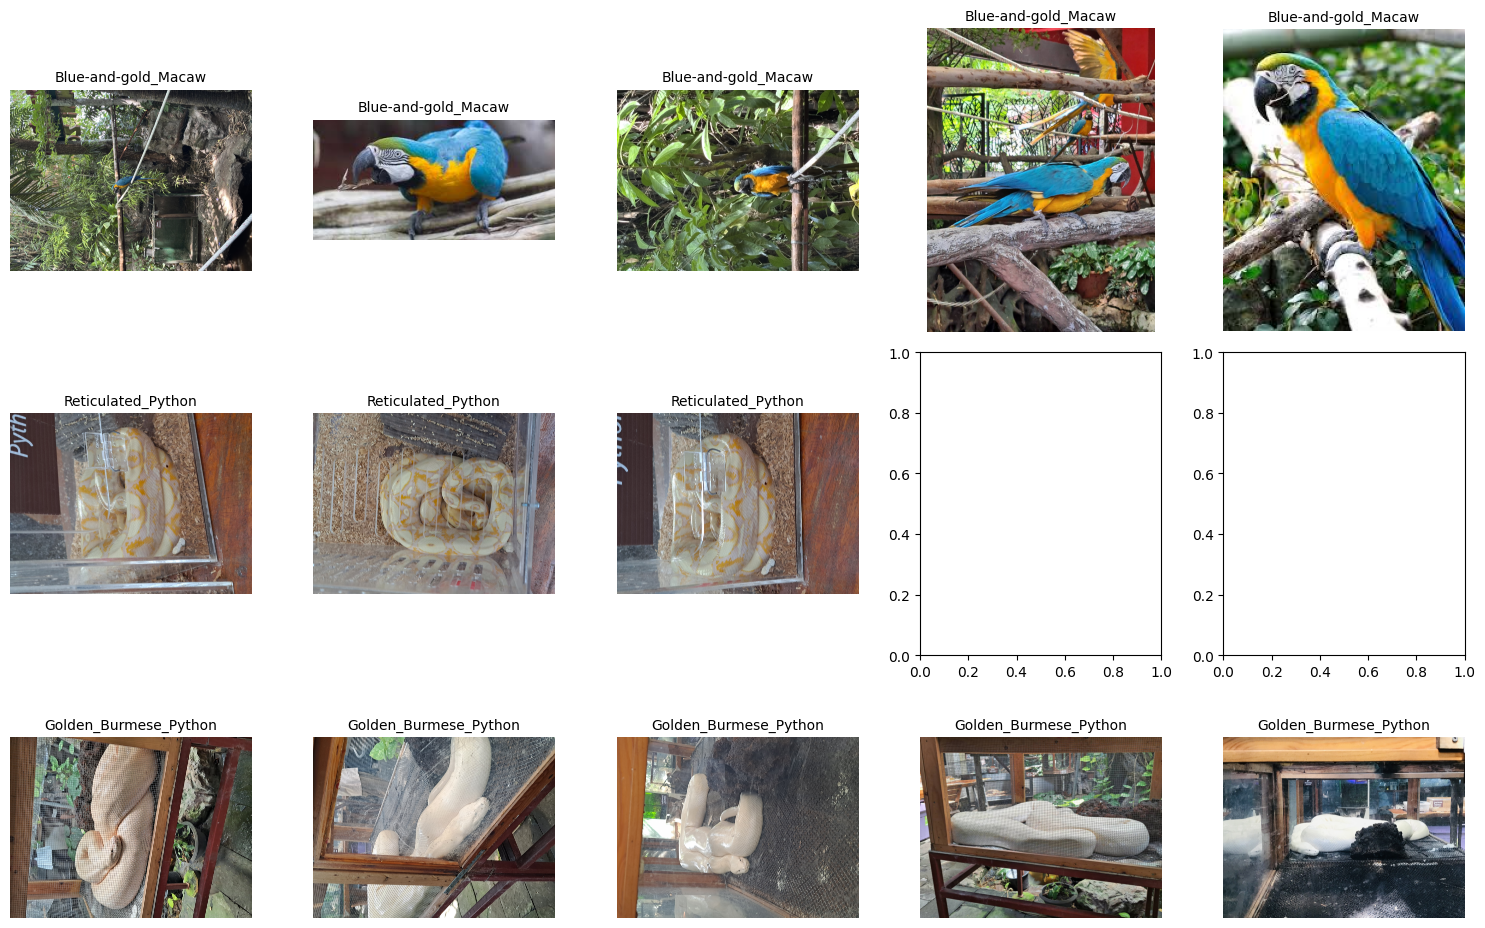

In [10]:
visual_eda(DATASET_PATH)

## Image Size Summary

In [11]:
def image_size_summary(base_path):
    base_path = Path(base_path)
    size_counter = Counter()
    total_images = 0

    for img_path in base_path.rglob("*"):
        if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
            continue

        try:
            with Image.open(img_path) as img:
                size_counter[f"{img.width}x{img.height}"] += 1
                total_images += 1
        except Exception:
            continue

    # Print summary
    print("Image Size Summary:\n")
    for size, count in size_counter.most_common():
        print(f"{size} : {count} images")

    print(f"\nTotal image files counted: {total_images}")

    return size_counter

In [12]:
image_size_summary(DATASET_PATH)

Image Size Summary:

4624x3468 : 598 images
4032x3024 : 181 images
1108x1477 : 154 images
5712x4284 : 138 images
3024x4032 : 50 images
275x183 : 8 images
225x225 : 6 images
1477x1108 : 5 images
259x194 : 4 images
4284x5712 : 3 images
794x854 : 3 images
456x654 : 3 images
290x174 : 2 images
300x168 : 2 images
284x177 : 1 images
199x253 : 1 images
196x257 : 1 images
194x259 : 1 images
1200x899 : 1 images
251x201 : 1 images
520x702 : 1 images
693x520 : 1 images
320x240 : 1 images
870x934 : 1 images
656x530 : 1 images
1006x1346 : 1 images
1002x1350 : 1 images
680x854 : 1 images
594x872 : 1 images
850x1200 : 1 images
990x1324 : 1 images
626x920 : 1 images
1198x1562 : 1 images
738x988 : 1 images
996x1334 : 1 images
822x680 : 1 images
1010x1344 : 1 images
1034x1568 : 1 images
526x604 : 1 images
724x600 : 1 images
596x900 : 1 images
183x275 : 1 images
600x900 : 1 images
214x235 : 1 images
417x626 : 1 images
201x251 : 1 images
183x276 : 1 images
600x400 : 1 images
500x375 : 1 images
318x159 : 1

Counter({'4624x3468': 598,
         '4032x3024': 181,
         '1108x1477': 154,
         '5712x4284': 138,
         '3024x4032': 50,
         '275x183': 8,
         '225x225': 6,
         '1477x1108': 5,
         '259x194': 4,
         '4284x5712': 3,
         '794x854': 3,
         '456x654': 3,
         '290x174': 2,
         '300x168': 2,
         '284x177': 1,
         '199x253': 1,
         '196x257': 1,
         '194x259': 1,
         '1200x899': 1,
         '251x201': 1,
         '520x702': 1,
         '693x520': 1,
         '320x240': 1,
         '870x934': 1,
         '656x530': 1,
         '1006x1346': 1,
         '1002x1350': 1,
         '680x854': 1,
         '594x872': 1,
         '850x1200': 1,
         '990x1324': 1,
         '626x920': 1,
         '1198x1562': 1,
         '738x988': 1,
         '996x1334': 1,
         '822x680': 1,
         '1010x1344': 1,
         '1034x1568': 1,
         '526x604': 1,
         '724x600': 1,
         '596x900': 1,
         '183x275': 

# 2. Data Filtering / Selection

## Quantity Filtering

In [13]:
def filter_and_prepare_dataset(src, dest):
    if not dest.exists():
        dest.mkdir(parents=True)
        print(f"Create a New Folder for Experiment: {dest}")

    print(f"Start filtering animals with images >= {NUMBER_OF_CLASS_SPLITS}...")
    print("-" * 50)
    
    selected_classes = 0
    total_images_copied = 0

    # Loop through all animal folders in the source
    for folder in sorted(src.iterdir()):
        # Skip Mac system files (.DS_Store) and other non-directory files
        if folder.is_dir() and not folder.name.startswith('.'):
            # Count only image files
            images = [f for f in folder.iterdir() 
                      if f.suffix.lower() in ['.jpg', '.jpeg', '.png'] 
                      and not f.name.startswith('.')]
            
            count = len(images)
            
            if count >= NUMBER_OF_CLASS_SPLITS:
                dest_folder = dest / folder.name
                
                # If the destination folder already exists, remove it and create a new one (to avoid duplicate data)
                if dest_folder.exists():
                    shutil.rmtree(dest_folder)
                
                shutil.copytree(folder, dest_folder)
                
                print(f"✅ {folder.name:<25} | {count:>3} Images [Copied]")
                selected_classes += 1
                total_images_copied += count
            else:
                # If it doesn't meet the criteria, show that it is skipped
                print(f"❌ {folder.name:<25} | {count:>3} Images [Below threshold - Skipped]")

    print("-" * 50)
    print(f"- Summary: Selected {selected_classes} classes")
    print(f"- Total images ready for training: {total_images_copied}")
    print(f"- Data located at: {dest}")

In [14]:
filter_and_prepare_dataset(DATASET_PATH_OBJ, DATASET_PLUS)

Create a New Folder for Experiment: /Users/smileymacz/Desktop/WildSnap-Train-40plus
Start filtering animals with images >= 40...
--------------------------------------------------
❌ African_Pygmy_Dormouse    |   4 Images [Below threshold - Skipped]
❌ Albino_Siamese_Crocodile  |  25 Images [Below threshold - Skipped]
❌ Ball_Python               |  35 Images [Below threshold - Skipped]
❌ Black-headed_Caique       |  29 Images [Below threshold - Skipped]
✅ Blue-and-gold_Macaw       |  84 Images [Copied]
❌ Blue-tongued_Skink        |  23 Images [Below threshold - Skipped]
❌ Budapest_Pigeon           |  22 Images [Below threshold - Skipped]
❌ Budgerigar                |  14 Images [Below threshold - Skipped]
❌ Burmese_Python            |  25 Images [Below threshold - Skipped]
❌ Cockatiel                 |   8 Images [Below threshold - Skipped]
❌ Cuviers_Dwarf_Caiman      |  22 Images [Below threshold - Skipped]
❌ Golden_Burmese_Python     |  19 Images [Below threshold - Skipped]
✅ Gouldian_

In [15]:
summarize_dataset(DATASET_PLUS)

----------------------------------------
Animal                    | Image Count
----------------------------------------
Blue-and-gold_Macaw       | 84         ✅ Ready
Gouldian_Finch            | 81         ✅ Ready
Grey_Crowned_Crane        | 53         ✅ Ready
Iguana                    | 73         ✅ Ready
Madagascar_Giant_Day_Gecko | 86         ✅ Ready
Meerkat                   | 83         ✅ Ready
Muscovy_Duck              | 67         ✅ Ready
Scarlet_Macaw             | 46         ✅ Ready
Silkie_Chicken            | 48         ✅ Ready
Sulphur-crested_Cockatoo  | 64         ✅ Ready
White-bellied_Caique      | 78         ✅ Ready
Yellow_Ring-necked_Parakeet | 80         ✅ Ready
----------------------------------------
Total: 12 categories | 843 images


In [16]:
summarize_file_extensions(DATASET_PLUS)

Counter({'.jpg': 518, '.jpeg': 296, '.heic': 37, '.png': 29, '.webp': 1})

In [17]:
find_broken_images(DATASET_PLUS)

[PosixPath('/Users/smileymacz/Desktop/WildSnap-Train-40plus/Gouldian_Finch/IMG_6015.HEIC'),
 PosixPath('/Users/smileymacz/Desktop/WildSnap-Train-40plus/Gouldian_Finch/IMG_6019.HEIC'),
 PosixPath('/Users/smileymacz/Desktop/WildSnap-Train-40plus/Gouldian_Finch/IMG_6018.HEIC'),
 PosixPath('/Users/smileymacz/Desktop/WildSnap-Train-40plus/Gouldian_Finch/.DS_Store'),
 PosixPath('/Users/smileymacz/Desktop/WildSnap-Train-40plus/Gouldian_Finch/IMG_6015 (3).HEIC'),
 PosixPath('/Users/smileymacz/Desktop/WildSnap-Train-40plus/Gouldian_Finch/IMG_6171.HEIC'),
 PosixPath('/Users/smileymacz/Desktop/WildSnap-Train-40plus/Gouldian_Finch/IMG_6014.HEIC'),
 PosixPath('/Users/smileymacz/Desktop/WildSnap-Train-40plus/Gouldian_Finch/IMG_6015 (1).HEIC'),
 PosixPath('/Users/smileymacz/Desktop/WildSnap-Train-40plus/Gouldian_Finch/IMG_6176.HEIC'),
 PosixPath('/Users/smileymacz/Desktop/WildSnap-Train-40plus/Gouldian_Finch/IMG_6009.HEIC'),
 PosixPath('/Users/smileymacz/Desktop/WildSnap-Train-40plus/Gouldian_Finch/I

# 3. Data Preprocessing

# Convert Image

In [18]:
register_heif_opener()

In [19]:
def convert_heic_to_jpg(folder_path):
    base_path = Path(folder_path).expanduser().resolve()

    if not base_path.exists():
        print(f"Folder not found: {base_path}")
        return

    files = [f for f in base_path.rglob("*") if f.suffix.lower() in ['.heic', '.heif']]

    if not files:
        print(f"Searching in: {base_path}")
        print("No .heic files found in this folder or its subfolders")

        for i, f in enumerate(base_path.rglob("*")):
            if i > 5: break
            print(f"- {f.name} (suffix: {f.suffix})")
        return

    print(f"Found a total of {len(files)} HEIC files, starting conversion...")

    for file in files:
        try:
            image = Image.open(file)
            
            target_path = file.with_suffix('.jpg')

            image.convert("RGB").save(target_path, "JPEG", quality=95)
            print(f"Converted successfully: {file.relative_to(base_path)} -> .jpg")

            os.remove(file)

        except Exception as e:
            print(f"❌ Error occurred with file {file.name}: {e}")

    print("\nConversion completed!")

In [20]:
convert_heic_to_jpg(DATASET_PLUS)

Found a total of 37 HEIC files, starting conversion...
Converted successfully: Gouldian_Finch/IMG_6015.HEIC -> .jpg
Converted successfully: Gouldian_Finch/IMG_6019.HEIC -> .jpg
Converted successfully: Gouldian_Finch/IMG_6018.HEIC -> .jpg
Converted successfully: Gouldian_Finch/IMG_6015 (3).HEIC -> .jpg
Converted successfully: Gouldian_Finch/IMG_6171.HEIC -> .jpg
Converted successfully: Gouldian_Finch/IMG_6014.HEIC -> .jpg
Converted successfully: Gouldian_Finch/IMG_6015 (1).HEIC -> .jpg
Converted successfully: Gouldian_Finch/IMG_6176.HEIC -> .jpg
Converted successfully: Gouldian_Finch/IMG_6009.HEIC -> .jpg
Converted successfully: Gouldian_Finch/IMG_6183.HEIC -> .jpg
Converted successfully: Gouldian_Finch/IMG_6013.HEIC -> .jpg
Converted successfully: Gouldian_Finch/IMG_6012.HEIC -> .jpg
Converted successfully: Gouldian_Finch/IMG_6182.HEIC -> .jpg
Converted successfully: Gouldian_Finch/IMG_6008.HEIC -> .jpg
Converted successfully: Gouldian_Finch/IMG_6015 (2).HEIC -> .jpg
Converted successf

In [21]:
summarize_file_extensions(DATASET_PLUS)

Counter({'.jpg': 555, '.jpeg': 296, '.png': 29, '.webp': 1})

## Resize Image to 214 x 214

In [22]:
def resize_and_pad(img_path, output_path, size=214):
    try:
        with Image.open(img_path) as img:
            # Convert to RGB (to handle PNG with Alpha channel or CMYK files)
            img = img.convert('RGB')
            
            # Calculate aspect ratio to resize the longest side to 214
            img.thumbnail((size, size), Image.Resampling.LANCZOS)
            
            # Fill with black background image of size 214x214
            new_img = Image.new("RGB", (size, size), (0, 0, 0))
            
            # Place the image in the center of the background
            left = (size - img.width) // 2
            top = (size - img.height) // 2
            new_img.paste(img, (left, top))
            
            new_img.save(output_path, "JPEG", quality=95)
    except Exception as e:
        print(f"❌ Can't process file {img_path.name}: {e}")

In [23]:
print("Defining image size to 214x214 with black background...")

if not DATASET_PLUS_SIZE.exists():
    DATASET_PLUS_SIZE.mkdir(parents=True)

for class_folder in sorted(DATASET_PLUS.iterdir()):
    if class_folder.is_dir() and not class_folder.name.startswith('.'):
        output_class_dir = DATASET_PLUS_SIZE / class_folder.name
        output_class_dir.mkdir(exist_ok=True)
        
        print(f"Processing: {class_folder.name}...")
        
        for img_file in class_folder.iterdir():
            if img_file.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                output_file_path = output_class_dir / f"{img_file.stem}.jpg"
                resize_and_pad(img_file, output_file_path, size=214)

print(f"\n Finished! All images are saved at: {DATASET_PLUS_SIZE}")

Defining image size to 214x214 with black background...
Processing: Blue-and-gold_Macaw...
Processing: Gouldian_Finch...
Processing: Grey_Crowned_Crane...
Processing: Iguana...
Processing: Madagascar_Giant_Day_Gecko...
Processing: Meerkat...
Processing: Muscovy_Duck...
Processing: Scarlet_Macaw...
Processing: Silkie_Chicken...
Processing: Sulphur-crested_Cockatoo...
Processing: White-bellied_Caique...
Processing: Yellow_Ring-necked_Parakeet...

 Finished! All images are saved at: /Users/smileymacz/Desktop/WildSnap-Final-214


In [24]:
image_size_summary(DATASET_PLUS_SIZE)

Image Size Summary:

214x214 : 880 images

Total image files counted: 880


Counter({'214x214': 880})

# 4. Data Augmentation

In [25]:
def augment_image(img):
    # Randomly flip image horizontally
    if random.random() > 0.5:
        img = ImageOps.mirror(img)
    
    # Randomly rotate image (-15 to 15 degrees)
    angle = random.randint(-15, 15)
    img = img.rotate(angle, fillcolor=(0,0,0)) # Rotate and fill black border
    
    # Randomly adjust brightness (0.8 to 1.2)
    enhancer = ImageEnhance.Brightness(img)
    img = enhancer.enhance(random.uniform(0.8, 1.2))
    
    return img

In [26]:
print(f"Starting Augmentation to ensure each class has at least {TARGET_COUNT} images...\n")

for class_folder in sorted(DATASET_PLUS_SIZE.iterdir()):
    if class_folder.is_dir() and not class_folder.name.startswith('.'):
        # Get the list of existing images
        images = [f for f in class_folder.iterdir() if f.suffix.lower() in ['.jpg', '.jpeg', '.png']]
        current_count = len(images)
        
        if current_count < TARGET_COUNT:
            num_to_add = TARGET_COUNT - current_count
            print(f"{class_folder.name}: has {current_count} images, adding {num_to_add} more...")
            
            for i in range(num_to_add):
                # Randomly select one original image to augment
                source_img_path = random.choice(images)
                with Image.open(source_img_path) as img:
                    augmented_img = augment_image(img)
                    
                    new_name = f"aug_{i}_{source_img_path.name}"
                    augmented_img.save(class_folder / new_name, "JPEG", quality=95)
        else:
            print(f"✅ {class_folder.name}: has enough images ({current_count} images)")

print(f"\nDone! Now every class in {DATASET_PLUS_SIZE} has at least {TARGET_COUNT} images.")

Starting Augmentation to ensure each class has at least 100 images...

Blue-and-gold_Macaw: has 84 images, adding 16 more...


✅ Gouldian_Finch: has enough images (112 images)
Grey_Crowned_Crane: has 59 images, adding 41 more...
Iguana: has 73 images, adding 27 more...
Madagascar_Giant_Day_Gecko: has 86 images, adding 14 more...
Meerkat: has 83 images, adding 17 more...
Muscovy_Duck: has 67 images, adding 33 more...
Scarlet_Macaw: has 46 images, adding 54 more...
Silkie_Chicken: has 48 images, adding 52 more...
Sulphur-crested_Cockatoo: has 64 images, adding 36 more...
White-bellied_Caique: has 78 images, adding 22 more...
Yellow_Ring-necked_Parakeet: has 80 images, adding 20 more...

Done! Now every class in /Users/smileymacz/Desktop/WildSnap-Final-214 has at least 100 images.


In [27]:
summarize_dataset(DATASET_PLUS_SIZE)

----------------------------------------
Animal                    | Image Count
----------------------------------------
Blue-and-gold_Macaw       | 100        ✅ Ready
Gouldian_Finch            | 112        ✅ Ready
Grey_Crowned_Crane        | 100        ✅ Ready
Iguana                    | 100        ✅ Ready
Madagascar_Giant_Day_Gecko | 100        ✅ Ready
Meerkat                   | 100        ✅ Ready
Muscovy_Duck              | 100        ✅ Ready
Scarlet_Macaw             | 100        ✅ Ready
Silkie_Chicken            | 100        ✅ Ready
Sulphur-crested_Cockatoo  | 100        ✅ Ready
White-bellied_Caique      | 100        ✅ Ready
Yellow_Ring-necked_Parakeet | 100        ✅ Ready
----------------------------------------
Total: 12 categories | 1212 images


# 5. Data Splitting

In [28]:
def split_dataset(input_folder, output_folder):
    if not output_folder.exists():
        output_folder.mkdir(parents=True)
    
    print("Splitting dataset with Train/Val/Test ratio of 80/10/10...")
    
    splitfolders.ratio(input_folder, output=output_folder, 
                       seed=1337, ratio=(.8, .1, .1), 
                       group_prefix=None, move=False)
    
    print("Dataset split completed.")

In [29]:
split_dataset(DATASET_PLUS_SIZE, DATASET_PLUS_SIZE_SPLIT)

Splitting dataset with Train/Val/Test ratio of 80/10/10...
Dataset split completed.


# 6. Data Loader

## Tensor Conversion & Normalization

In [78]:
class ApplyCLAHE(object):
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clip_limit = clip_limit
        self.tile_grid_size = tile_grid_size

    def __call__(self, img):
        img_array = np.array(img.convert('RGB'))
        
        lab = cv2.cvtColor(img_array, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        
        clahe = cv2.createCLAHE(clipLimit=self.clip_limit, tileGridSize=self.tile_grid_size)
        cl = clahe.apply(l)
        
        limg = cv2.merge((cl, a, b))
        final_img = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
        
        return Image.fromarray(final_img)

In [31]:
def define_normalization_transforms():
    data_transforms = {
        'train': transforms.Compose([
            ApplyCLAHE(clip_limit=3.0),
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1), 
            transforms.RandomGrayscale(p=0.1),
            transforms.ToTensor(),
            transforms.Normalize(NORM_MEAN, NORM_STD)
        ]),
        'val': transforms.Compose([
            ApplyCLAHE(clip_limit=3.0),
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1), 
            transforms.RandomGrayscale(p=0.1),
            transforms.ToTensor(),
            transforms.Normalize(NORM_MEAN, NORM_STD)
        ]),
    }

    print("✅ Normalization transforms defined successfully")
    return data_transforms

In [32]:
data_transforms = define_normalization_transforms()
data_transforms

✅ Normalization transforms defined successfully


{'train': Compose(
     Resize(size=(214, 214), interpolation=bilinear, max_size=None, antialias=True)
     RandomHorizontalFlip(p=0.5)
     ColorJitter(brightness=(0.7, 1.3), contrast=(0.7, 1.3), saturation=(0.7, 1.3), hue=(-0.1, 0.1))
     RandomGrayscale(p=0.1)
     ToTensor()
     Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
 ),
 'val': Compose(
     Resize(size=(214, 214), interpolation=bilinear, max_size=None, antialias=True)
     RandomHorizontalFlip(p=0.5)
     ColorJitter(brightness=(0.7, 1.3), contrast=(0.7, 1.3), saturation=(0.7, 1.3), hue=(-0.1, 0.1))
     RandomGrayscale(p=0.1)
     ToTensor()
     Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
 )}

In [33]:
# Create Dataset with transforms (including Normalization)
image_datasets = {
    x: datasets.ImageFolder(DATASET_PLUS_SIZE_SPLIT / x, data_transforms[x])
    for x in ['train', 'val']
}

# 2. Create DataLoader (data conveyor belt)
dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=16, shuffle=True)
    for x in ['train', 'val']
}

In [34]:
# Analyze dataset sizes and classes
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

print(f"Summary of normalized data:")
print(f"- Number of Classes: {len(class_names)} types")
print(f"- Training images: {dataset_sizes['train']} images")
print(f"- Validation images: {dataset_sizes['val']} images")

Summary of normalized data:
- Number of Classes: 12 types
- Training images: 969 images
- Validation images: 121 images


# 7. Define Model

In [35]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"🚀 Using Device: {device}")

# Load pre-trained EfficientNet-B0 model
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# Adjust the classifier head to match the number of your animal classes
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, len(class_names))

# Move the model to GPU/CPU
model = model.to(device)

# 4. Define Loss function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"✅ Model defined successfully, ready to classify {len(class_names)} animal types")

🚀 Using Device: mps
✅ Model defined successfully, ready to classify 12 animal types


# 8. Start Training

In [36]:
def train_model(model, criterion, optimizer, num_epochs=10):
    since = time.time()
    
    # Store training history
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                # Forward Pass (let AI predict)
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward Pass (fine-tune only during training)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.cpu().float() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

    time_elapsed = time.time() - since
    print(f'\nTraining completed in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    return model, history

In [37]:
# Start training (try starting with 10-15 epochs first)
trained_model, train_history = train_model(model, criterion, optimizer, num_epochs=15)

Epoch 1/15
----------
train Loss: 0.9348 Acc: 0.7461
val Loss: 0.3467 Acc: 0.9091
Epoch 2/15
----------
train Loss: 0.3876 Acc: 0.8937
val Loss: 0.2090 Acc: 0.9256
Epoch 3/15
----------
train Loss: 0.2853 Acc: 0.9082
val Loss: 0.2859 Acc: 0.9587
Epoch 4/15
----------
train Loss: 0.2928 Acc: 0.9082
val Loss: 0.1961 Acc: 0.9421
Epoch 5/15
----------
train Loss: 0.2035 Acc: 0.9401
val Loss: 0.2422 Acc: 0.9421
Epoch 6/15
----------
train Loss: 0.1374 Acc: 0.9598
val Loss: 0.1568 Acc: 0.9421
Epoch 7/15
----------
train Loss: 0.0890 Acc: 0.9711
val Loss: 0.0211 Acc: 0.9917
Epoch 8/15
----------
train Loss: 0.1129 Acc: 0.9742
val Loss: 0.0838 Acc: 0.9752
Epoch 9/15
----------
train Loss: 0.1004 Acc: 0.9670
val Loss: 0.1147 Acc: 0.9504
Epoch 10/15
----------
train Loss: 0.1018 Acc: 0.9659
val Loss: 0.1144 Acc: 0.9669
Epoch 11/15
----------
train Loss: 0.1037 Acc: 0.9763
val Loss: 0.2039 Acc: 0.9339
Epoch 12/15
----------
train Loss: 0.1005 Acc: 0.9721
val Loss: 0.1194 Acc: 0.9587
Epoch 13/15
-

# 9. Result Testing

## Learning Curves Result

In [38]:
def plot_history(history):
    acc = history['train_acc']
    val_acc = history['val_acc']
    loss = history['train_loss']
    val_loss = history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))
    
    # Accuracy graph
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    # Loss graph
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    
    plt.show()

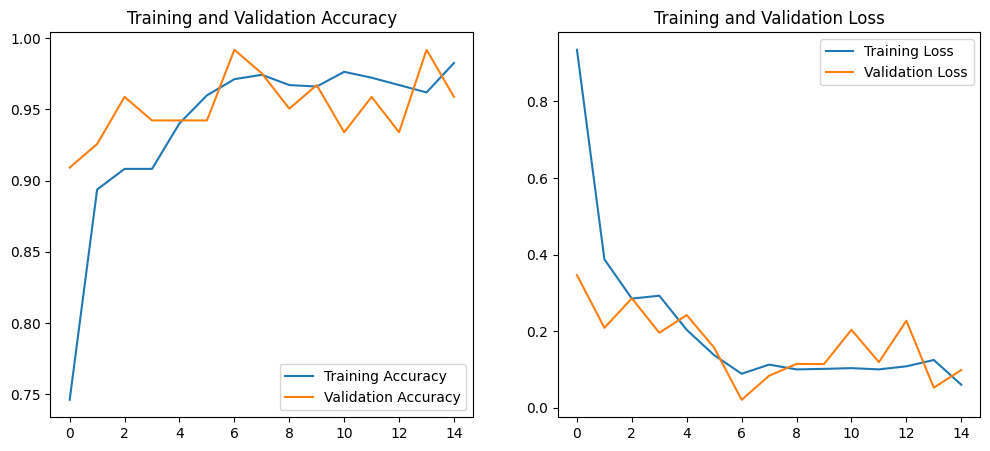

In [39]:
plot_history(train_history)

## Confusion Matrix

In [40]:
def show_confusion_matrix(model, dataloader):
    model.eval()
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

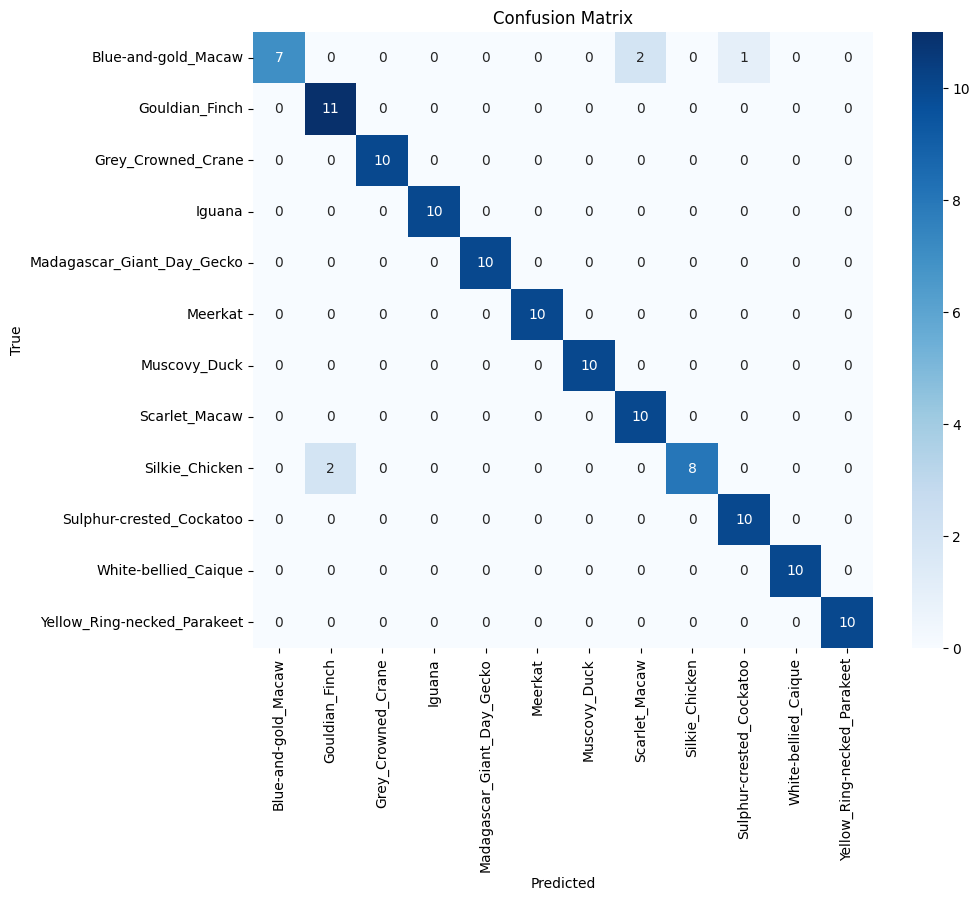

In [41]:
show_confusion_matrix(trained_model, dataloaders['val'])

## Test Model

In [42]:
test_dataset = datasets.ImageFolder(DATASET_PLUS_SIZE_SPLIT / 'test', data_transforms['val'])

test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"Number of images in the final test set: {len(test_dataset)} images")

Number of images in the final test set: 122 images


In [43]:
def evaluate_test_set(model, dataloader):
    model.eval()
    running_corrects = 0
    
    print("Starting test evaluation...")
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            running_corrects += torch.sum(preds == labels.data)
            
    test_acc = running_corrects.cpu().float() / len(dataloader.dataset)
    print(f"\nTest Set Accuracy (unseen data): {test_acc:.4f} ({test_acc*100:.2f}%)")
    return test_acc

In [44]:
final_test_acc = evaluate_test_set(trained_model, test_dataloader)

Starting test evaluation...

Test Set Accuracy (unseen data): 0.9836 (98.36%)


In [45]:
def evaluate_test_set_internet(model, image_path):
    img = Image.open(image_path).convert('RGB')
    # Use the same transform as validation (Resize + Normalize)
    transform = data_transforms['val']
    img_tensor = transform(img).unsqueeze(0).to(device)
    
    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        prob = torch.nn.functional.softmax(output[0], dim=0)
        conf, pred = torch.max(prob, 0)
    
    plt.imshow(img)
    plt.title(f"Prediction: {class_names[pred]} ({conf*100:.2f}%)")
    plt.axis('off')
    plt.show()

## Test with Animal in the Model

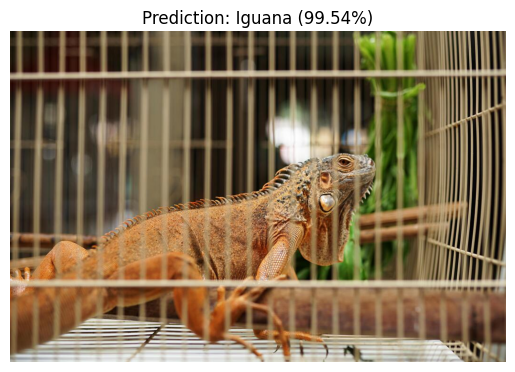

In [46]:
test_image = Path("~/Downloads/iguana01.jpeg").expanduser()
evaluate_test_set_internet(trained_model, test_image)

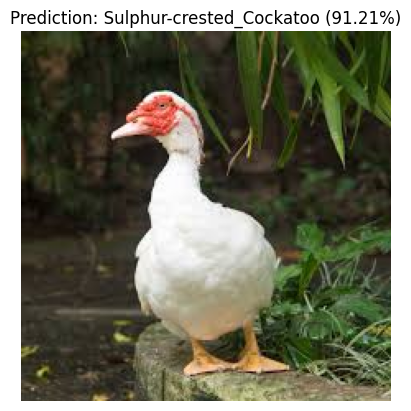

In [52]:
test_image = Path("~/Downloads/duck01.jpeg").expanduser()
evaluate_test_set_internet(trained_model, test_image)

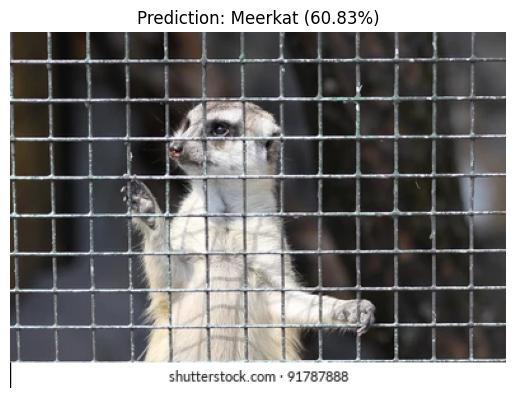

In [68]:
test_image = Path("~/Downloads/meerkat01.webp").expanduser()
evaluate_test_set_internet(trained_model, test_image)

## Test with unknow Animal in Model

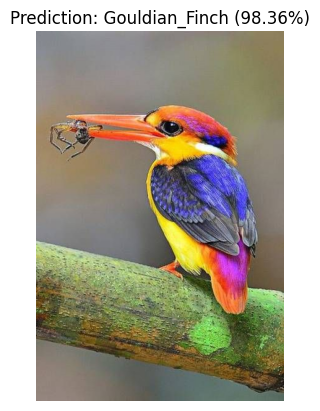

In [70]:
test_image = Path("~/Downloads/unknow-bird.jpg").expanduser()
evaluate_test_set_internet(trained_model, test_image)

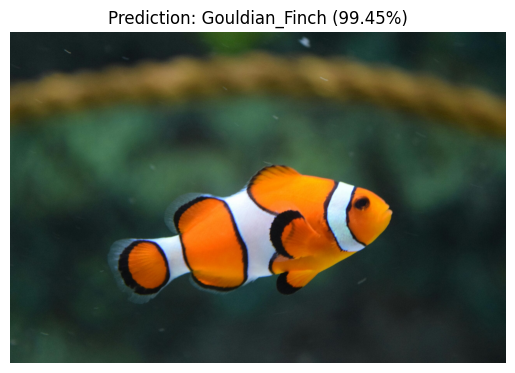

In [77]:
test_image = Path("~/Downloads/fish.jpg").expanduser()
evaluate_test_set_internet(trained_model, test_image)

# 10. Save Model

In [51]:
# Save the trained model
torch.save(trained_model.state_dict(), EXPORT_MODEL)
print(f"Saved the trained model as {EXPORT_MODEL}")

Saved the trained model as wildsnap_model.pth
